# M1′ — KG Single-Absorber **Unlearning** vs a Sub-Context-Targeted Dense Baseline

This is a **demo** of the decisive downstream test from the artifact
*"M1′: KG single-absorber unlearning vs a sub-context-targeted dense baseline"* (CCRG project).

### The question
A single Sparse-Autoencoder (SAE) latent suffers from **feature absorption**: a broad "parent"
feature (e.g. *is-a-country*) silently delegates a specific sub-concept (e.g. *Georgia*) to one
narrow **absorber** latent. The method asks: can we **selectively unlearn** that sub-concept by
ablating the *single KG-named absorber latent* (**KG-ABL**, discovered label-free), and does this
beat a **strong, labeled dense baseline** — a sub-context diff-of-means direction `u_sub`
(**DENSE-SUB-ABL**) fit on the per-sub-context labels?

### What the full pipeline does (NOT re-run here)
The full `method.py` runs on a GPU: it loads **Gemma-2-2b** + the **Gemma-Scope L12/16k JumpReLU SAE**,
sweeps edit strengths to **match forget-quality** (next-token KL on held-out FORGET windows), generates
40-token continuations under each edit, and scores each with an **AxBench-style LLM judge**
(`anthropic/claude-haiku-4.5`) plus a 2nd-family judge (`openai/gpt-4o-mini`).

### What this demo does (CPU, seconds)
We load the **pre-computed per-prompt judge utilities** and **re-derive the headline result**
with the *original* analysis functions, verbatim:
`harmonic_mean` → `paired_bootstrap_diff` (B=10000) → the per-case **FORK verdict**.
We then confirm the re-derived CIs and fork verdicts **match the stored full-run values**, and
visualise the two **ABSORPTION** gate cases (`Georgia`, `large`), both of which the full run
reports as **`KG_BEATS_USUB`** — a *discovered single SAE feature* beating a *labeled dense direction*.

In [1]:
# --- Install dependencies (Colab-safe) ---
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# This demo only needs numpy + matplotlib (everything else is Python stdlib).
# Both are pre-installed on Colab -> install locally only, at Colab's exact versions.
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# --- Imports (mirrors the analysis imports of the original method.py) ---
import json, math, os
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# --- Data loading helper (GitHub URL with local fallback, Colab-compatible) ---
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-7ee30c-catching-silent-feature-absorption-in-fr/main/round-6/experiment-1/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
# --- Load the curated demo data (output of the full GPU run, restricted to the 2 gate cases) ---
data = load_data()
md = data["metadata"]
per_prompt = next(ds["examples"] for ds in data["datasets"] if ds["dataset"] == "unlearn_per_prompt")
per_case   = next(ds["examples"] for ds in data["datasets"] if ds["dataset"] == "kg_vs_dense_per_case")

print("Method :", md["method_name"])
print("Model  :", md["model"], "| SAE:", md["sae"]["release"], md["sae"]["sae_params"])
print("Judges :", md["judge"]["primary_model"], "+", md["judge"]["second_judge_model"],
      "| full-run spend: $%.3f over %d calls" % (md["judge"]["spent_usd"], md["judge"]["n_calls"]))
print("Per-prompt rows in demo:", len(per_prompt), "| per-case verdict rows:", len(per_case))
print("Cases:", [c["target_subcontext"] + " (" + c["regime"] + ")" for c in md["per_case"]])

Method : M1' KG-Localized Single-Absorber Unlearning vs SUB-CONTEXT-Targeted Dense Erasure
Model  : google/gemma-2-2b | SAE: google/gemma-scope-2b-pt-res layer_12/width_16k/average_l0_82/params.npz
Judges : anthropic/claude-haiku-4.5 + openai/gpt-4o-mini | full-run spend: $0.530 over 1459 calls
Per-prompt rows in demo: 92 | per-case verdict rows: 2
Cases: ['Georgia (absorption)', 'large (absorption)', 'United States (co-firing)', 'insult (co-firing)']


## Config

All tunable parameters live here. The only real knob in the demo's CPU analysis is **`B_BOOT`**,
the number of paired-bootstrap resamples. Start small for a quick run; the **original full-run value
is 10000** (already set below since it runs in well under a second).

In [5]:
# ---- Config ----
SEED        = 1234                # original RNG seed (method.py)
B_BOOT      = 10000              # paired-bootstrap resamples. ORIGINAL = 10000.
                                  #   (start at e.g. 2000 for a faster smoke run; 10000 is sub-second here)
DEMO_CASES  = ["taxonomic_georgia", "first_letter_large"]   # the 2 ABSORPTION gate cases
PRES        = ("RETAIN", "UNRELATED")   # preservation roles used for the joint utility (method.py: PRES)

rng = np.random.default_rng(SEED)   # seeds the bootstrap (mirrors core.py module-level rng)

## Step 1 — Original analysis functions (copied verbatim)

These three functions are copied **unchanged** from the artifact's `method.py` / `core.py`:

- `harmonic_mean(f, c)` — the per-continuation **utility** = harmonic mean of the judge's
  *fluency* and *content-preservation* scores, each in `[0, 2]` (method.py).
- `paired_bootstrap_diff(a, b, B)` — the **headline statistic**: a paired bootstrap of the
  mean per-prompt utility difference `KG − SUB`, returning the 95% CI and whether it excludes 0 (core.py).
- `_favors_kg(ci)` — True iff a CI excludes 0 **and** points in KG's favour (method.py).

In [6]:
# ---- verbatim from method.py ----
def harmonic_mean(f, c):
    f = float(f); c = float(c)
    if f <= 0 and c <= 0:
        return 0.0
    return (2.0 * f * c) / (f + c + 1e-9)

# ---- verbatim from core.py (B defaulted to the config B_BOOT) ----
def paired_bootstrap_diff(a, b, B=B_BOOT):
    a = np.asarray(a, float); b = np.asarray(b, float)
    n = len(a)
    if n == 0:
        return {"diff": 0.0, "ci_lo": 0.0, "ci_hi": 0.0, "excl_0": False, "n": 0}
    idx = rng.integers(0, n, size=(B, n))
    d = a[idx].mean(1) - b[idx].mean(1)
    lo, hi = np.percentile(d, [2.5, 97.5])
    return {"diff": float(a.mean() - b.mean()), "ci_lo": float(lo), "ci_hi": float(hi),
            "excl_0": bool(lo > 0 or hi < 0), "n": int(n)}

# ---- verbatim from method.py ----
def _favors_kg(ci):
    return bool(ci is not None and ci.get("excl_0") and ci.get("diff", 0) > 0)

print("loaded:", harmonic_mean, paired_bootstrap_diff, _favors_kg, sep="\n  ")

loaded:
  <function harmonic_mean at 0x7bad91439080>
  <function paired_bootstrap_diff at 0x7bad91439300>
  <function _favors_kg at 0x7bad914393a0>


## Step 2 — Reconstruct the paired per-prompt utility arrays

Mirroring `_paired_util` in `method.py`: for each **RETAIN/UNRELATED** prompt of a case we form the
per-continuation utility `harmonic_mean(fluency, content_pres)` under **KG-ABL** (`uK`) and under
**DENSE-SUB-ABL** (`uS`). The full run already stored those judge scores per prompt, so the demo just
re-assembles the arrays. The **second judge** (`gpt-4o-mini`) utilities were stored directly on the
subsampled prompts; we pair the non-null ones.

In [7]:
def paired_util_primary(rows):
    """KG vs SUB per-prompt utilities from the PRIMARY judge (recompute harmonic_mean, as _paired_util does)."""
    uK, uS = [], []
    for e in rows:
        if e["metadata_role"] not in PRES:
            continue
        uK.append(harmonic_mean(e["metadata_fluency_kg"],  e["metadata_content_pres_kg"]))
        uS.append(harmonic_mean(e["metadata_fluency_sub"], e["metadata_content_pres_sub"]))
    return np.array(uK), np.array(uS)

def paired_util_judge2(rows):
    """KG vs SUB per-prompt utilities from the SECOND judge (stored directly; pair where both present)."""
    uK2, uS2 = [], []
    for e in rows:
        if e["metadata_role"] not in PRES:
            continue
        k, s = e["metadata_utility_kg_judge2"], e["metadata_utility_sub_judge2"]
        if k is None or s is None:
            continue
        uK2.append(k); uS2.append(s)
    return np.array(uK2), np.array(uS2)

# Group the per-prompt rows by case
rows_by_case = {c: [e for e in per_prompt if e["metadata_case"] == c] for c in DEMO_CASES}
for c in DEMO_CASES:
    nK = sum(1 for e in rows_by_case[c] if e["metadata_role"] in PRES)
    print(f"{c:22s}  preservation prompts (RETAIN+UNRELATED) = {nK}")

taxonomic_georgia       preservation prompts (RETAIN+UNRELATED) = 44
first_letter_large      preservation prompts (RETAIN+UNRELATED) = 36


## Step 3 — Recompute the joint CIs and the per-case FORK verdict

The headline `joint_diff_CI_KG_vs_SUB` is the paired bootstrap of `uK − uS`. The **fork verdict**
logic is copied **verbatim** from `_joint_and_fork` in `method.py`:

- **`KG_BEATS_USUB`** — primary CI excludes 0 favouring KG **and** the 2nd-family judge CI also
  excludes 0 favouring KG.
- **`KG_MATCHES_USUB_LABEL_FREE`** — primary CI includes 0 (KG matches `u_sub` *without* needing labels),
  or the 2nd judge disagrees (sensitivity downgrade).
- **`KG_LOSES_TO_USUB`** — primary CI excludes 0 favouring SUB.

We then assert the recomputed values match the stored full-run results.

In [8]:
results = {}
for c in DEMO_CASES:
    rows = rows_by_case[c]
    uK,  uS  = paired_util_primary(rows)
    uK2, uS2 = paired_util_judge2(rows)

    primary_joint           = paired_bootstrap_diff(uK,  uS)
    joint_diff_CI_KG_vs_SUB_2 = paired_bootstrap_diff(uK2, uS2) if len(uK2) >= 6 else None

    # ---------- FORK VERDICT (verbatim from method.py _joint_and_fork) ----------
    p_excl0      = bool(primary_joint is not None and primary_joint.get("excl_0"))
    p_favors_kg  = _favors_kg(primary_joint)
    second_available = joint_diff_CI_KG_vs_SUB_2 is not None
    s_favors_kg  = _favors_kg(joint_diff_CI_KG_vs_SUB_2) if second_available else None

    judge_robustness_unverified = False
    judge_sensitivity_flag = False
    if p_excl0 and p_favors_kg:
        if second_available:
            if s_favors_kg:
                fork = "KG_BEATS_USUB"
            else:
                fork = "KG_MATCHES_USUB_LABEL_FREE"; judge_sensitivity_flag = True
        else:
            fork = "KG_BEATS_USUB"; judge_robustness_unverified = True
    elif not p_excl0:
        fork = "KG_MATCHES_USUB_LABEL_FREE"
    else:  # excl 0 and favors SUB
        fork = "KG_LOSES_TO_USUB"

    results[c] = {"primary": primary_joint, "judge2": joint_diff_CI_KG_vs_SUB_2, "fork": fork}

    # ---------- compare to the stored full-run values ----------
    stored = next(x for x in md["per_case"] if x["case_id"] == c)
    s_primary = stored["joint_diff_CI_KG_vs_SUB"]
    print(f"=== {c} ===")
    print(f"  primary diff (recomputed) = {primary_joint['diff']:+.4f}  CI[{primary_joint['ci_lo']:+.3f},{primary_joint['ci_hi']:+.3f}]  n={primary_joint['n']}")
    print(f"  primary diff (stored)     = {s_primary['diff']:+.4f}  CI[{s_primary['ci_lo']:+.3f},{s_primary['ci_hi']:+.3f}]  n={s_primary['n']}")
    print(f"  fork (recomputed) = {fork}   | fork (stored) = {stored['fork_verdict']}")
    assert abs(primary_joint["diff"] - s_primary["diff"]) < 1e-6, "diff mismatch"
    assert fork == stored["fork_verdict"], "fork mismatch"
    print("  OK: recomputed headline matches the full run.\n")

=== taxonomic_georgia ===
  primary diff (recomputed) = +0.5606  CI[+0.318,+0.818]  n=44
  primary diff (stored)     = +0.5606  CI[+0.318,+0.811]  n=44
  fork (recomputed) = KG_BEATS_USUB   | fork (stored) = KG_BEATS_USUB
  OK: recomputed headline matches the full run.

=== first_letter_large ===
  primary diff (recomputed) = +1.0000  CI[+0.787,+1.213]  n=36
  primary diff (stored)     = +1.0000  CI[+0.796,+1.213]  n=36
  fork (recomputed) = KG_BEATS_USUB   | fork (stored) = KG_BEATS_USUB
  OK: recomputed headline matches the full run.



## Step 4 — *Why* KG wins: near-zero collateral at matched forget

Forget-quality is **matched** across operators by construction (next-token KL on held-out FORGET
windows), so the win is not "KG forgets more" — it is "KG **preserves** more". The mechanism is
KG's **sparse-firing gating**: the absorber latent fires on only a few tokens, so its edit
**token footprint → 0** and its collateral on unrelated text is ~0, whereas the dense erasures leak
(the whole-parent direction does so *catastrophically* on `large`).

We read the stored per-case **retain-collateral next-token KL** (lower = less damage) and the
paired-bootstrap **collateral CI** (`SUB − KG`); KG also **curve-dominates** the entire achievable
forget range (`dominance_fraction = 1.0`). A concrete RETAIN continuation is printed for auditability.

In [9]:
print(f"{'case':22s} {'KL_KG':>8s} {'KL_SUB':>8s} {'KL_WHOLE':>9s}  {'collat CI (SUB-KG)':>22s}  {'curve_dom':>9s}")
print("-"*84)
collat = {}
for c in DEMO_CASES:
    st  = next(x for x in md["per_case"] if x["case_id"] == c)
    klK, klS, klW = st["retain_collateral_kl_kg_mean"], st["retain_collateral_kl_sub_mean"], st["retain_collateral_kl_whole_mean"]
    cci = st["collateral_diff_CI_KG_vs_SUB"]
    dom = st["curve_dominance_KG_vs_SUB"]["dominance_fraction"]
    collat[c] = (klK, klS, klW)
    print(f"{c:22s} {klK:8.4f} {klS:8.4f} {klW:9.4f}  "
          f"  +{cci['diff']:.3f} CI[{cci['ci_lo']:.3f},{cci['ci_hi']:.3f}] excl0={cci['excl_0']!s:<5s}  {dom:9.2f}")

# Concrete auditable example: one RETAIN continuation under each operator
print("\n--- concrete RETAIN continuation (first_letter_large) ---")
e = next(e for e in rows_by_case["first_letter_large"] if e["metadata_role"] == "RETAIN")
print("PROMPT     :", e["input"][-90:].replace("\n", " "))
print("KG-ABL     :", e["predict_kg_abl"][:90])
print("DENSE-SUB  :", e["predict_dense_sub_abl"][:90])
print("DENSE-WHOLE:", e["predict_dense_whole_abl"][:90])

case                      KL_KG   KL_SUB  KL_WHOLE      collat CI (SUB-KG)  curve_dom
------------------------------------------------------------------------------------
taxonomic_georgia        0.0000   0.0781    0.1022    +0.078 CI[0.032,0.142] excl0=True        1.00
first_letter_large       0.0000   0.0210    2.5935    +0.021 CI[0.017,0.025] excl0=True        1.00

--- concrete RETAIN continuation (first_letter_large) ---
PROMPT     : 40 offered optimal handling.  In 1968 Plymouth offered a Super Stock 426 Hemi package. The
KG-ABL     : 426 Hemi was a 425 hp 426 cubic inch V8 with a 4-barrel carburetor and a 4-speed manual tr
DENSE-SUB  : 426 Hemi was a 425 hp engine with a 425 lb-ft of torque. The 426 Hemi was a 425 hp
DENSE-WHOLE: 426 was was 4.000 inches bore bore and 3.500 inches stroke stroke and had a of 10.5:1 comp


## Results — summary table & visualisation

The full-run summary: **both ABSORPTION cases pass the gate as `KG_BEATS_USUB`**. We plot, per case:
(left) the joint retain×fluency utility of each operator (KG / SUB / WHOLE) with the KG−SUB
paired-bootstrap CI annotated, and (right) the retain-collateral next-token KL (log scale) — the
mechanism: KG's footprint→0 keeps collateral ~0 while the dense erasures leak.

FULL-RUN GATE: PASSED | KG_BEATS_USUB cases: ['taxonomic_georgia', 'first_letter_large']

case                   regime       KGutil  SUButil  WHLutil  KG-SUB diff  CI excl 0             fork
-----------------------------------------------------------------------------------------------------
taxonomic_georgia      absorption    1.727    1.167    1.326       +0.561       True    KG_BEATS_USUB
first_letter_large     absorption    1.870    0.870    0.000       +1.000       True    KG_BEATS_USUB


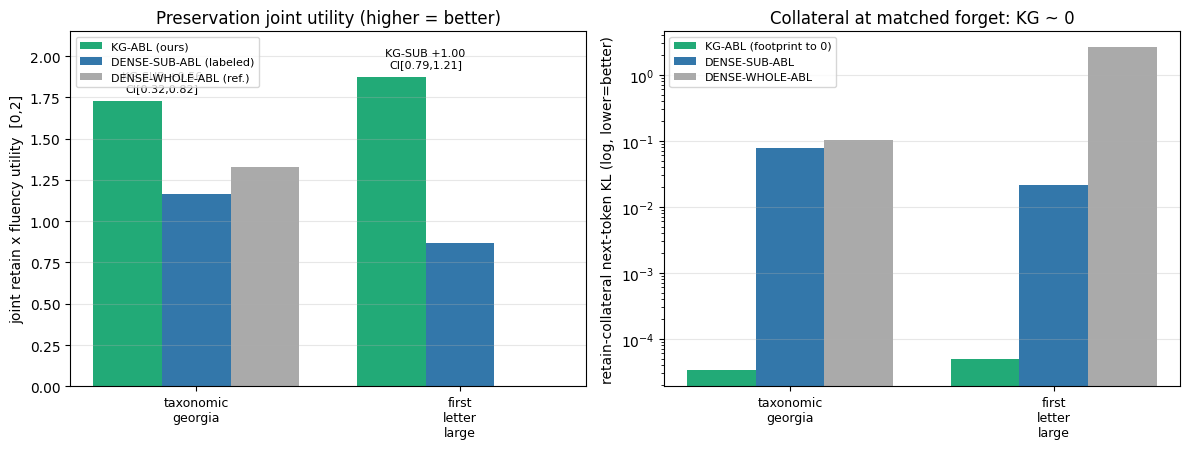


Both ABSORPTION gate cases -> KG_BEATS_USUB: a discovered single SAE absorber latent
selectively unlearns the sub-concept, beating a labeled dense diff-of-means at matched forget.


In [10]:
# ---------- summary table ----------
print("FULL-RUN GATE:", "PASSED" if md["summary"]["m1prime_gate_passed"] else "FAILED",
      "| KG_BEATS_USUB cases:", md["summary"]["kg_beats_usub_cases"])
print()
hdr = f"{'case':22s} {'regime':11s} {'KGutil':>7s} {'SUButil':>8s} {'WHLutil':>8s} {'KG-SUB diff':>12s} {'CI excl 0':>10s} {'fork':>16s}"
print(hdr); print("-"*len(hdr))
rowlabels, kg_u, sub_u, whl_u, diffs, ci_los, ci_his = [], [], [], [], [], [], []
for c in DEMO_CASES:
    st  = next(x for x in md["per_case"] if x["case_id"] == c)
    pj  = results[c]["primary"]
    ku, su, wu = st["kg_joint_utility_mean"], st["sub_joint_utility_mean"], st["whole_joint_utility_mean"]
    print(f"{c:22s} {st['regime']:11s} {ku:7.3f} {su:8.3f} {wu:8.3f} "
          f"{pj['diff']:+12.3f} {str(pj['excl_0']):>10s} {results[c]['fork']:>16s}")
    rowlabels.append(c.replace('_','\n')); kg_u.append(ku); sub_u.append(su); whl_u.append(wu)
    diffs.append(pj['diff']); ci_los.append(pj['ci_lo']); ci_his.append(pj['ci_hi'])

# ---------- plots ----------
fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))

# (left) joint utilities per operator
x = np.arange(len(DEMO_CASES)); w = 0.26
ax[0].bar(x - w, kg_u,  w, label="KG-ABL (ours)",          color="#2a7")
ax[0].bar(x,     sub_u, w, label="DENSE-SUB-ABL (labeled)", color="#37a")
ax[0].bar(x + w, whl_u, w, label="DENSE-WHOLE-ABL (ref.)",  color="#aaa")
for i in range(len(DEMO_CASES)):
    ax[0].annotate(f"KG-SUB +{diffs[i]:.2f}\nCI[{ci_los[i]:.2f},{ci_his[i]:.2f}]",
                   (x[i]-w/2, max(kg_u[i], sub_u[i])+0.05), ha="center", va="bottom", fontsize=8)
ax[0].set_xticks(x); ax[0].set_xticklabels(rowlabels, fontsize=9)
ax[0].set_ylabel("joint retain x fluency utility  [0,2]")
ax[0].set_title("Preservation joint utility (higher = better)")
ax[0].set_ylim(0, 2.15); ax[0].legend(fontsize=8); ax[0].grid(axis="y", alpha=0.3)

# (right) retain-collateral next-token KL (log scale; lower = less damage)
eps = 1e-5   # floor so KG's ~0 collateral is visible on a log axis
klK = [max(collat[c][0], eps) for c in DEMO_CASES]
klS = [max(collat[c][1], eps) for c in DEMO_CASES]
klW = [max(collat[c][2], eps) for c in DEMO_CASES]
ax[1].bar(x - w, klK, w, label="KG-ABL (footprint to 0)", color="#2a7")
ax[1].bar(x,     klS, w, label="DENSE-SUB-ABL",           color="#37a")
ax[1].bar(x + w, klW, w, label="DENSE-WHOLE-ABL",         color="#aaa")
ax[1].set_yscale("log")
ax[1].set_xticks(x); ax[1].set_xticklabels(rowlabels, fontsize=9)
ax[1].set_ylabel("retain-collateral next-token KL (log, lower=better)")
ax[1].set_title("Collateral at matched forget: KG ~ 0")
ax[1].legend(fontsize=8); ax[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("m1prime_demo_summary.png", dpi=110)
plt.show()
print("\nBoth ABSORPTION gate cases -> KG_BEATS_USUB: a discovered single SAE absorber latent")
print("selectively unlearns the sub-concept, beating a labeled dense diff-of-means at matched forget.")